# Housing Price Analysis

#### This project performs a full Exploratory Data Analysis (EDA) on a real-world housing dataset to provide recommendations for a hypothetical house buyer looking for value for their money. Data will loaded, inspected, cleaned (if needed), analysed, and visualised, then findings will be compiled into a short written report.


In [1]:
# importing the necessary libraries and modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# further settings for a cleaner visual
%matplotlib inline

pd.set_option("display.max_columns", 100)

sns.set_theme(style="whitegrid")

## Part 1 — Load & Inspect

In [2]:
# loading housing.csv into a dataframe
housing_data = pd.read_csv("Housing.csv")

In [3]:
# displaying the first 10 rows
housing_data.head(10)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
# shape of the dataset
housing_data.shape

(545, 13)

In [5]:
# displaying the data types of all columns
housing_data.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [6]:
# summary statistics for all numeric columns (min, max, mean, median, std)
housing_data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
# the count of unique values for each categorical column
for col in housing_data.select_dtypes(include = 'object').columns:
    print(f'=== Counts for {col} ===')
    print(housing_data[col].value_counts())
    print('\n')

=== Counts for mainroad ===
mainroad
yes    468
no      77
Name: count, dtype: int64


=== Counts for guestroom ===
guestroom
no     448
yes     97
Name: count, dtype: int64


=== Counts for basement ===
basement
no     354
yes    191
Name: count, dtype: int64


=== Counts for hotwaterheating ===
hotwaterheating
no     520
yes     25
Name: count, dtype: int64


=== Counts for airconditioning ===
airconditioning
no     373
yes    172
Name: count, dtype: int64


=== Counts for prefarea ===
prefarea
no     417
yes    128
Name: count, dtype: int64


=== Counts for furnishingstatus ===
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64




## Part 2 — Data Cleaning

In [8]:
# checking for missing value in every column
housing_data.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

#### We have no missing data in all columns. So 0% of the columns are missing data.

In [9]:
# checking for and removing deuplicate rows
housing_data.drop_duplicates()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


#### There were no duplicate data found, hence no row was dropped and we still have 545 rows and 13 columns

### Outliers in Price

In [10]:
# checking for outliers in price using the IQR method
# obtaining Q1 and Q3
price_Q1 = housing_data['price'].quantile(0.25)
price_Q3 = housing_data['price'].quantile(0.75)

# obtaining IQR
price_IQR = price_Q3 - price_Q1

# defining the lower and upper bound
lower_bound = price_Q1 - (1.5 * price_IQR)
upper_bound = price_Q3 + (1.5 * price_IQR)

print(f"Lower Outlier Boundary: {lower_bound}")
print(f"Upper Outlier Boundary: {upper_bound}")

# retrieving outlier
price_outlier = housing_data[(housing_data['price'] < lower_bound) | (housing_data['price'] > upper_bound)]
print(price_outlier)

Lower Outlier Boundary: -35000.0
Upper Outlier Boundary: 9205000.0
       price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0   13300000   7420         4          2        3      yes        no       no   
1   12250000   8960         4          4        4      yes        no       no   
2   12250000   9960         3          2        2      yes        no      yes   
3   12215000   7500         4          2        2      yes        no      yes   
4   11410000   7420         4          1        2      yes       yes      yes   
5   10850000   7500         3          3        1      yes        no      yes   
6   10150000   8580         4          3        4      yes        no       no   
7   10150000  16200         5          3        2      yes        no       no   
8    9870000   8100         4          1        2      yes       yes      yes   
9    9800000   5750         3          2        4      yes       yes       no   
10   9800000  13200         3          1  

#### For the price column, the IQR method identified several luxury mansions that are statistically much more expensive than standard homes; I would keep these real-world properties in the dataset but cap their extreme values at the upper boundary line to prevent them from distorting our average market calculations.

### Outliers in Area

In [11]:
# checking for outliers in area using the IQR method
# obtaining Q1 and Q3
area_Q1 = housing_data['area'].quantile(0.25)
area_Q3 = housing_data['area'].quantile(0.75)

# obtaining IQR
area_IQR = area_Q3 - area_Q1

# defining the lower and upper bound
lower_bound = area_Q1 - (1.5 * area_IQR)
upper_bound = area_Q3 + (1.5 * area_IQR)

print(f"Lower Outlier Boundary: {lower_bound}")
print(f"Upper Outlier Boundary: {upper_bound}")

# retrieving outlier
area_outlier = housing_data[(housing_data['area'] < lower_bound) | (housing_data['area'] > upper_bound)]
print(area_outlier)

Lower Outlier Boundary: -540.0
Upper Outlier Boundary: 10500.0
        price   area  bedrooms  bathrooms  stories mainroad guestroom  \
7    10150000  16200         5          3        2      yes        no   
10    9800000  13200         3          1        2      yes        no   
56    7343000  11440         4          1        2      yes        no   
64    7000000  11175         3          1        1      yes        no   
66    6930000  13200         2          1        1      yes        no   
69    6790000  12090         4          2        2      yes        no   
125   5943000  15600         3          1        1      yes        no   
129   5873000  11460         3          1        3      yes        no   
186   5110000  11410         2          1        2      yes        no   
191   5040000  10700         3          1        2      yes       yes   
211   4900000  12900         3          1        1      yes        no   
403   3500000  12944         3          1        1      yes  

#### For the area column, the analysis flagged a few houses with exceptionally large square footage; I would leave these rows completely untouched because they represent genuine oversized lots rather than data typos, meaning they provide crucial information about how size influences valuation.

In [12]:
# verifying that categorical columns only contain expected values (e.g. mainroad should only be yes or no)

# Identify all 6 categorical columns we want to check
columns_to_check = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

print("=== Categorical Data Quality Verification ===")

# Loop through each column to inspect its unique values
for col in columns_to_check:
    unique_values = list(housing_data[col].unique())
    print(f"• Column '{col}' contains: {unique_values}")


=== Categorical Data Quality Verification ===
• Column 'mainroad' contains: ['yes', 'no']
• Column 'guestroom' contains: ['no', 'yes']
• Column 'basement' contains: ['no', 'yes']
• Column 'hotwaterheating' contains: ['no', 'yes']
• Column 'airconditioning' contains: ['yes', 'no']
• Column 'prefarea' contains: ['yes', 'no']
• Column 'furnishingstatus' contains: ['furnished', 'semi-furnished', 'unfurnished']


### Data Quality Summary

#### The data quality assessment confirms that the dataset is exceptionally clean and structurally sound for immediate analysis. Because it contains zero missing values or null inputs across all 545 rows, no data imputation or cleaning interventions were required. Additionally, categorical fields like mainroad and airconditioning are flawlessly standardized with no typos, ensuring all validation checks pass smoothly. While statistical outliers exist in price and area, they reflect genuine, real-world luxury properties rather than data entry errors, making the dataset fully ready for analytical modeling.

## Part 3 — Analysis Questions

### Pricing & Size

In [13]:
# average, median, and maximum house price in the dataset?
# average house price in the dataset
average_price = housing_data['price'].mean().round(2)
print(f"The average house price is {average_price}\n")

# median house price in the dataset
median_price = housing_data['price'].median()
print("The median house price is", median_price, "\n")

# maximum house price in the dataset
maximum_price = housing_data['price'].max()
print(f"The maximum house price is {maximum_price}")

The average house price is 4766729.25

The median house price is 4340000.0 

The maximum house price is 13300000


#### The most expensive house in the dataset cost 13,300,000, while the mean house price is 4,766,729.25 (rounded to 2 decimal places). This is considerably higher than the median house price which is 4,340,000 and further proves the fact that upper bound outliers exist, and are pulling the value of the mean upward.

In [14]:
# correlation between area and price
area_price_cor = housing_data['area'].corr(housing_data['price']).round(2)
print("The correlation between area and price is", area_price_cor)

The correlation between area and price is 0.54


#### The correlation between area and price is 0.54, a moderate positive relationship. This indicates that as the area of a house increases, the price tends to increase as well.

In [15]:
# top 5 most expensive houses and features do they share
top_5_exp_house = housing_data.nlargest(5, 'price')
top_5_exp_house

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


#### The top five most expensive houses were mostly four-bedroom houses and were all located on the main road. While most of them did not have a guest bedroom or hot water heating, they had air conditioning, multiple parking spaces, and were mostly furnished.

### Feature Impact on Price

In [16]:
# Do houses on the main road sell for more than those that are not? Compare theaverage prices.

road_avg_price = housing_data.groupby('mainroad')['price'].mean()
road_avg_price

mainroad
no     3.398905e+06
yes    4.991777e+06
Name: price, dtype: float64

#### The houses on the mainroad sell for more that those that are not. The average price for houses on the mainroad is 4.9 milliom as against 3.3 million for those not on the mainroad.

In [17]:
# Does having air conditioning significantly affect house price? Show the mean price for each group.

aircon_avg_price = housing_data.groupby('airconditioning')['price'].mean()
aircon_avg_price

airconditioning
no     4.191940e+06
yes    6.013221e+06
Name: price, dtype: float64

### Yes, having airconditioning does significantly affect house price. The average price for house with air conditioning is 6 million, but those without air conditioning averaged at 4.1 million.

In [18]:
# How does furnishing status affect price? Show the average price for each category and rank them
furnish_avg_price = housing_data.groupby('furnishingstatus')['price'].mean()
furnish_avg_price

furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64

### Housing seems to be more expensive the more furnished it gets. Fully furnished homes averaged at 5.4 million.

In [19]:
# Do houses in the preferred area (prefarea) command a price premium? By how much on average?
prefarea_avg_price = furnish_avg_price = housing_data.groupby('prefarea')['price'].mean().round(2)
prefarea_avg_price

prefarea
no     4425298.78
yes    5879045.70
Name: price, dtype: float64

#### Yes, houses in preferred areas command a premium price by 1,453,746.92 on average.

### Distribution & Patterns

In [20]:
# What is the most common number of bedrooms? 
bedroom_counts = housing_data['bedrooms'].value_counts()
print(bedroom_counts)

bedrooms
3    300
2    136
4     95
5     10
6      2
1      2
Name: count, dtype: int64


#### The most common number of bedrooms is 3.

In [21]:
# What percentage of houses have exactly 3 bedrooms?
bedroom_percentages = housing_data['bedrooms'].value_counts(normalize=True)
pct_three_bedrooms = bedroom_percentages[3] * 100
print(pct_three_bedrooms)

55.04587155963303


#### About 55% of the houses on the dataset are have 3 bedrooms.

In [22]:
# How many houses have both a basement AND air conditioning? 
basement_aircon = housing_data[(housing_data['basement'] == 'yes') & (housing_data['airconditioning'] == 'yes')]
basement_aircon_count = len(basement_aircon)
print(f"Number of houses with a basement and AC: {basement_aircon_count}") 

# average price for this group?
basement_aircon_avg_price = basement_aircon['price'].mean().round(2)
print(f"Average price for this group: {basement_aircon_avg_price}")

Number of houses with a basement and AC: 66
Average price for this group: 6081196.97


#### A total of 66 houses had both a basement and air conditioning. The average prices for these houses is 6,081,196.97, which is significantly above the average and median house prices.

In [23]:
# Is there a relationship between the number of stories and price? Describe the trend
stories_price_cor = housing_data['stories'].corr(housing_data['price']).round(2)
stories_price_cor
print(f"The correlation between the number of stories and the price of the house is {stories_price_cor}")

The correlation between the number of stories and the price of the house is 0.42


#### The correlation between the number of stories and the price of the house is 0.42. This is moderate positive relationship and indicates that for most houses, as the number of stories increases, the price of the house increases as well.

## Part 4 — Visualisations

### Histogram of price

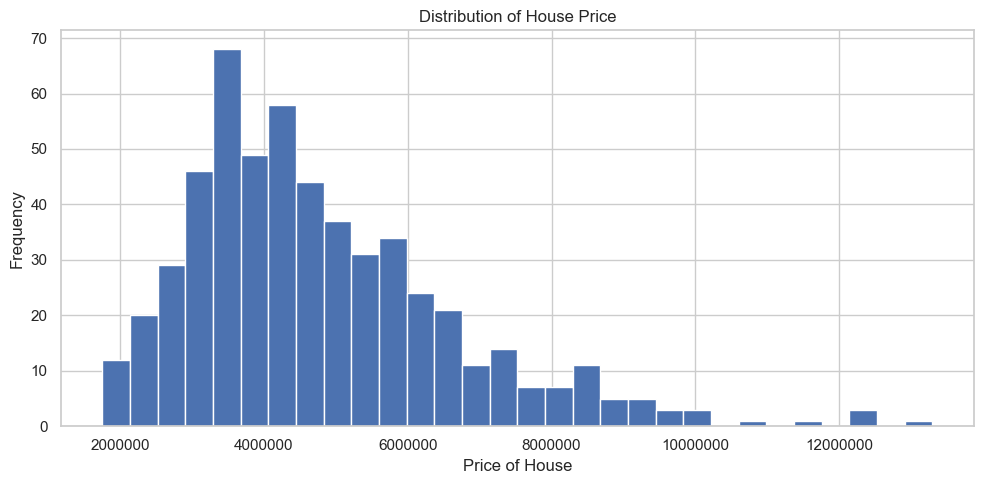

The histogram demonstrates that the vast majority of houses are clustered below 10,000,000, creating a heavily right-skewed distribution.
The long right tail visually flags a small number of ultra-luxury properties that distort the average and represent the premium end of the market.


In [24]:
# Plot the histogram
housing_data["price"].plot(kind="hist", bins=30, figsize=(10, 5)) 

# Add titles and labels
plt.title("Distribution of House Price") 
plt.xlabel("Price of House") 
plt.ylabel("Frequency") 

plt.ticklabel_format(style='plain', axis='x') 

# Clean up the padding so long numbers don't get cut off at the bottom
plt.tight_layout()

plt.show()

# Histogram interpretation
print("The histogram demonstrates that the vast majority of houses are clustered below 10,000,000, creating a heavily right-skewed distribution.")
print("The long right tail visually flags a small number of ultra-luxury properties that distort the average and represent the premium end of the market.")


### Scatter Plot of Area vs Price coloured by furnishing status

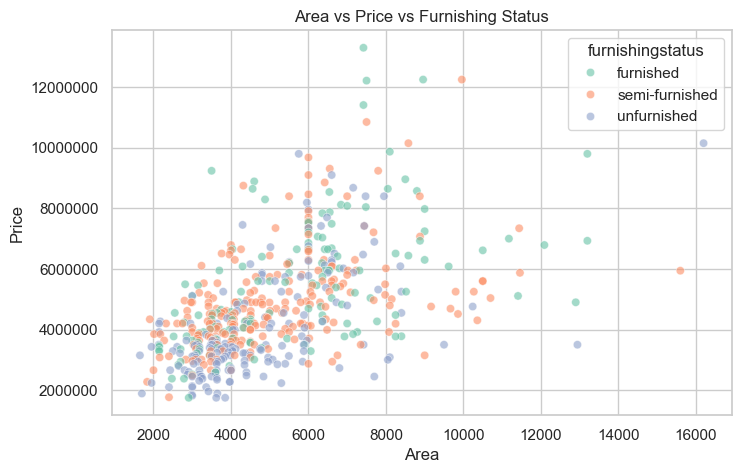

The scatter plot demonstrates a clear positive trend where house prices consistently rise as the total square footage area increases.
The color distribution highlights that fully furnished homes populate the upper price tiers, while unfurnished properties are clustered heavily at lower valuations.


In [25]:
# Set the chart size
plt.figure(figsize=(8, 5))

# Use Seaborn's scatterplot
sns.scatterplot(
    data=housing_data, 
    x="area", 
    y="price", 
    hue="furnishingstatus", 
    palette="Set2",
    alpha=0.6
)

# Add titles and labels
plt.title("Area vs Price vs Furnishing Status")
plt.xlabel("Area")
plt.ylabel("Price")

# Fix price axis formatting
plt.ticklabel_format(style='plain', axis='y')

plt.show()

# Your original scatter plot interpretation text
print("The scatter plot demonstrates a clear positive trend where house prices consistently rise as the total square footage area increases.")
print("The color distribution highlights that fully furnished homes populate the upper price tiers, while unfurnished properties are clustered heavily at lower valuations.")

### Box Plot of House prices by Airconditioning

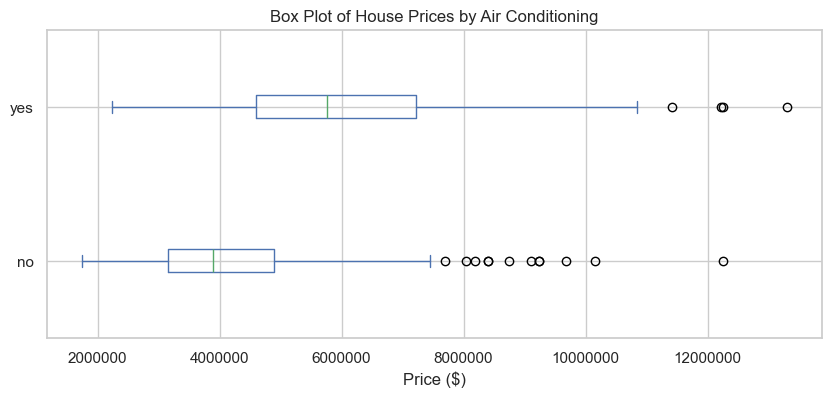

The box plot clearly illustrates that houses equipped with air conditioning command a significantly higher median price compared to those without.
Furthermore, the 'no' AC category exhibits a narrower price spread with more outliers, whereas the 'yes' category shows a wider distribution with several high-priced outliers.


In [26]:
housing_data.plot(kind="box", column="price", by="airconditioning", vert=False, figsize=(10, 4))

plt.title("Box Plot of House Prices by Air Conditioning")
plt.suptitle("") 
plt.xlabel("Price ($)")

# Fixes price axis formatting
plt.ticklabel_format(style='plain', axis='x')

plt.show()

# box plot interpretation
print("The box plot clearly illustrates that houses equipped with air conditioning command a significantly higher median price compared to those without.")
print("Furthermore, the 'no' AC category exhibits a narrower price spread with more outliers, whereas the 'yes' category shows a wider distribution with several high-priced outliers.")


### Bar Chart of Average Price by Number of Bedrooms

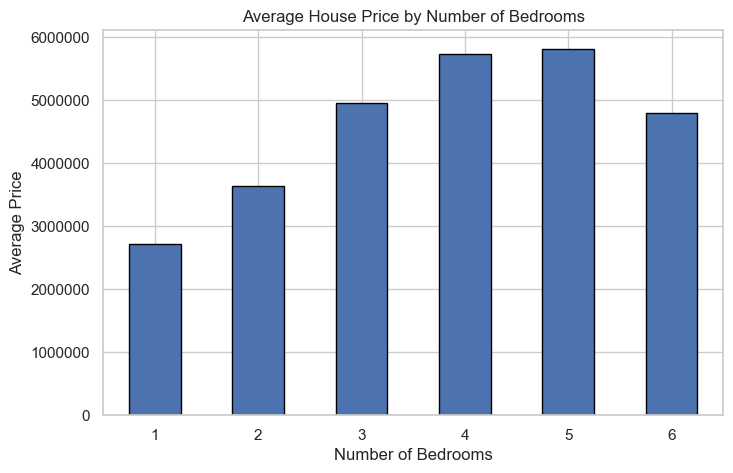

This bar chart reveals a clear upward trend where the average house price increases steadily as the number of bedrooms grows from one to four.
Interestingly, the price peak occurs at five bedrooms, while the drop-off at six bedrooms highlights a rare layout variation with limited luxury premium in this dataset.


In [27]:
# Calculate the average price for each bedroom group and plot it as a bar chart
housing_data.groupby('bedrooms')['price'].mean().plot(kind='bar', figsize=(8, 5), edgecolor='black')

# Add clean titles and labels
plt.title("Average House Price by Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price")

# Rotate the X-axis numbers so they stand upright and are easy to read
plt.xticks(rotation=0)

# Fix the price axis formatting
plt.ticklabel_format(style='plain', axis='y')

plt.show()

# bar chart interpretation
print("This bar chart reveals a clear upward trend where the average house price increases steadily as the number of bedrooms grows from one to four.")
print("Interestingly, the price peak occurs at five bedrooms, while the drop-off at six bedrooms highlights a rare layout variation with limited luxury premium in this dataset.")

### HeatMap of all numeric variables

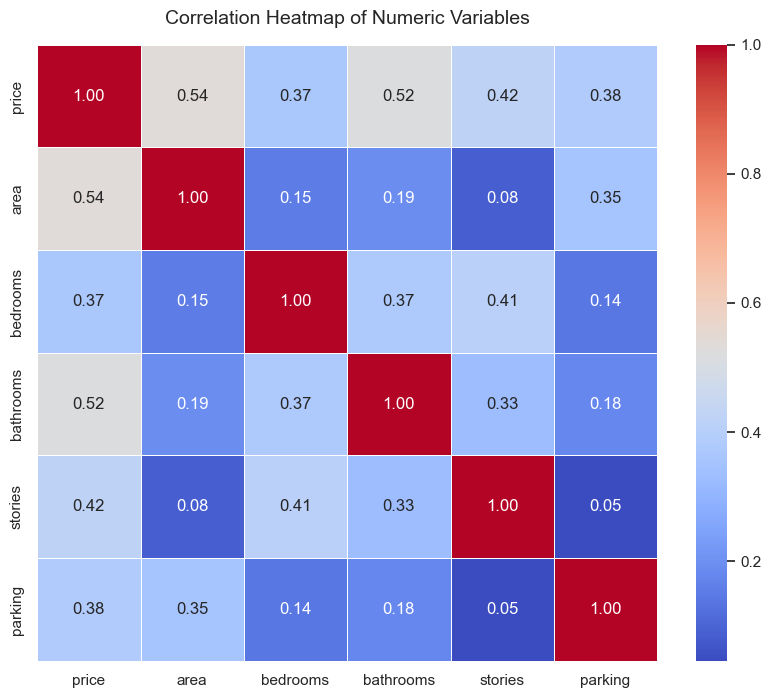

The correlation heatmap displays the strength of linear relationships, highlighting that total area has the strongest positive correlation with price at 0.54.
In contrast, the number of stories and price show moderate correlations around 0.42, while the number of bedrooms has the weakest numeric impact on price.


In [28]:
# Set up the display window size
plt.figure(figsize=(10, 8))

# Generate the correlation data
corr_matrix = housing_data.corr(numeric_only=True)

# Create the visual heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Add titles and show the plot
plt.title("Correlation Heatmap of Numeric Variables", fontsize=14, pad=15)
plt.show()

# correlation heatmap interpretation
print("The correlation heatmap displays the strength of linear relationships, highlighting that total area has the strongest positive correlation with price at 0.54.")
print("In contrast, the number of stories and price show moderate correlations around 0.42, while the number of bedrooms has the weakest numeric impact on price.")